# ML Assignment 2 — Model Training

**Name:** Akhil Jain | **BITS ID:** 2025ac05543 | **Course:** Machine Learning (AIMLCZG565)

## Problem Statement
Build and compare multiple classification models on a single dataset, expose them through an
interactive Streamlit app, and deploy the app publicly.

## Dataset Description
**Breast Cancer Wisconsin (Diagnostic) Dataset** — a binary classification dataset (malignant
vs benign tumor) originally hosted on the UCI Machine Learning Repository, bundled with
scikit-learn (`sklearn.datasets.load_breast_cancer`).

- Instances: 569 (≥ 500 required)
- Features: 30 numeric features computed from digitized images of a breast mass fine needle
  aspirate (radius, texture, perimeter, area, smoothness, etc., each reported as mean,
  standard error, and "worst"/largest value) — (≥ 12 required)
- Target: 0 = malignant, 1 = benign (212 malignant / 357 benign)

Loading it through scikit-learn (rather than downloading a CSV) keeps this notebook fully
reproducible with no internet dependency — important since it also needs to run on the BITS
Virtual Lab.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                              recall_score, f1_score, matthews_corrcoef,
                              confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import joblib
import os

RANDOM_STATE = 42
os.makedirs("model", exist_ok=True)
os.makedirs("data", exist_ok=True)

## Load Dataset

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0 = malignant, 1 = benign

print("Shape:", X.shape)
print("\nClass balance:\n", y.value_counts())
X.head()

Shape: (569, 30)

Class balance:
 target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Train / Test Split and Scaling
80/20 stratified split (keeps the malignant/benign ratio consistent across train and test).
Features are standardized since Logistic Regression and kNN are distance/coefficient based.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, "model/scaler.pkl")

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (455, 30)  Test shape: (114, 30)


## Train 5 Classification Models
Logistic Regression, Decision Tree, k-Nearest Neighbors, Naive Bayes (Gaussian), and an
ensemble Random Forest — all trained on the same train/test split for a fair comparison.

In [4]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "kNN": KNeighborsClassifier(n_neighbors=7),
    "Naive Bayes": GaussianNB(),
    "Random Forest (Ensemble)": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

results = []
confusion_matrices = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)

    results.append({
        "ML Model Name": name, "Accuracy": acc, "AUC": auc,
        "Precision": prec, "Recall": rec, "F1": f1, "MCC": mcc
    })
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)

    fname = name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    joblib.dump(model, f"model/{fname}.pkl")

print("All 5 models trained and saved to model/")

All 5 models trained and saved to model/


## Evaluation Metrics — Comparison Table

In [5]:
results_df = pd.DataFrame(results).round(4)
results_df.to_csv("data/comparison_table.csv", index=False)
results_df

,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9825,0.9954,0.9861,0.9861,0.9861,0.9623
1,Decision Tree,0.9123,0.9157,0.9559,0.9028,0.9286,0.8174
2,kNN,0.9737,0.9884,0.9600,1.0000,0.9796,0.9442
3,Naive Bayes,0.9298,0.9868,0.9444,0.9444,0.9444,0.8492
4,Random Forest (Ensemble),0.9561,0.9932,0.9589,0.9722,0.9655,0.9054


## Confusion Matrices

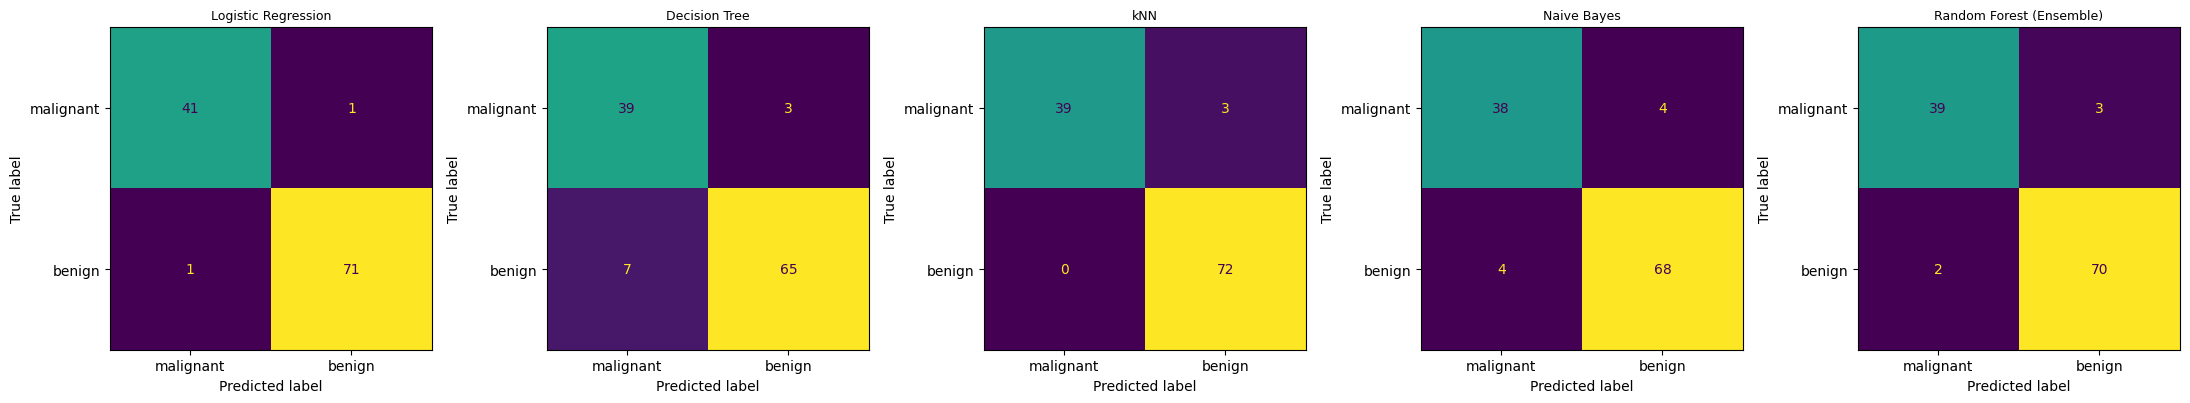

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["malignant", "benign"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=9)
plt.tight_layout()
plt.savefig("data/confusion_matrices.png", dpi=120)
plt.show()

## Save Test Data
Saved separately for use in the Streamlit app's "upload CSV" demo — this is the held-out 20%
test split (unscaled features + true label), never seen during training.

In [7]:
test_data = X_test.copy()
test_data["target"] = y_test.values
test_data.to_csv("data/test_data.csv", index=False)
print("Saved data/test_data.csv with shape:", test_data.shape)
test_data.head()

Saved data/test_data.csv with shape: (114, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
256,19.55,28.77,133.60,1207.0,0.09260,0.20630,0.17840,0.11440,0.1893,0.06232,...,36.27,178.60,1926.0,0.1281,0.53290,0.4251,0.19410,0.2818,0.10050,0
428,11.13,16.62,70.47,381.1,0.08151,0.03834,0.01369,0.01370,0.1511,0.06148,...,20.29,74.35,421.1,0.1030,0.06219,0.0458,0.04044,0.2383,0.07083,1
501,13.82,24.49,92.33,595.9,0.11620,0.16810,0.13570,0.06759,0.2275,0.07237,...,32.94,106.00,788.0,0.1794,0.39660,0.3381,0.15210,0.3651,0.11830,0
363,16.50,18.29,106.60,838.1,0.09686,0.08468,0.05862,0.04835,0.1495,0.05593,...,25.45,117.20,1009.0,0.1338,0.16790,0.1663,0.09123,0.2394,0.06469,1
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.1410,0.21130,0.4107,0.22160,0.2060,0.07115,0


## Observations

- **Logistic Regression** achieved the highest accuracy (0.9825) and AUC (0.9954) on this
  dataset. The 30 features are strongly linearly separable after standardization, so a linear
  decision boundary works very well and generalizes cleanly on the held-out test set.
- **Decision Tree** was the weakest model (accuracy 0.9123, MCC 0.8174). A single
  unconstrained tree overfits to noise in the training split; without pruning or depth limits
  it captures spurious splits that don't generalize, which shows up as more false negatives.
- **kNN** performed strongly (accuracy 0.9737, Recall 1.0000). After scaling, the benign vs
  malignant classes form fairly tight, well-separated clusters in feature space, so
  distance-based neighbor voting is very effective. Its perfect recall means it caught every
  benign case; its slightly lower precision means a few malignant cases were misclassified as
  benign-neighbors.
- **Naive Bayes** trailed the top models (accuracy 0.9298) despite a good AUC (0.9868) — the
  Gaussian independence assumption is a simplification, since many of these 30 features
  (e.g., mean radius and mean perimeter) are highly correlated, which Naive Bayes cannot
  model.
- **Random Forest (Ensemble)** was a strong, well-balanced performer (accuracy 0.9561,
  MCC 0.9054) — bagging many trees reduces the overfitting seen in the single Decision Tree,
  though it didn't quite match Logistic Regression / kNN on this particular split.

**Overall winner for this dataset: Logistic Regression** — best accuracy, AUC, and MCC,
indicating the classes are close to linearly separable once scaled, so the extra complexity
of tree ensembles or non-parametric methods isn't needed here.